<a href="https://colab.research.google.com/github/vsharma4394/Alphaswap/blob/main/AlphaVariant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

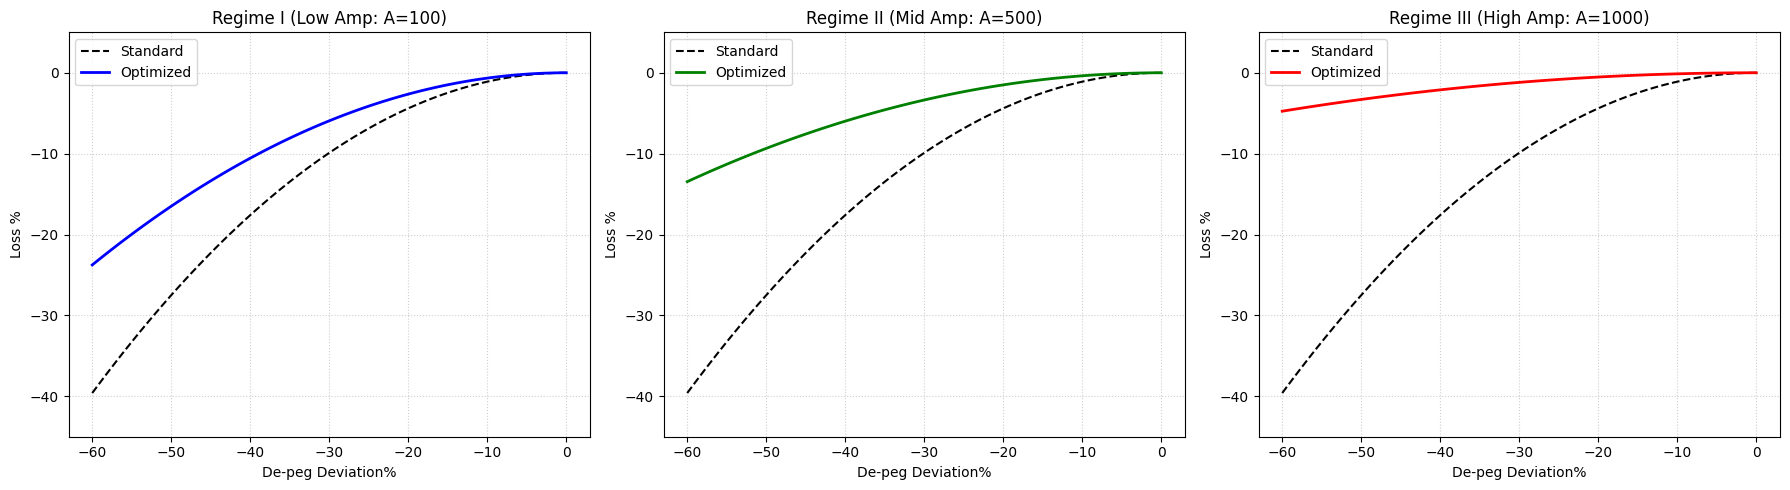

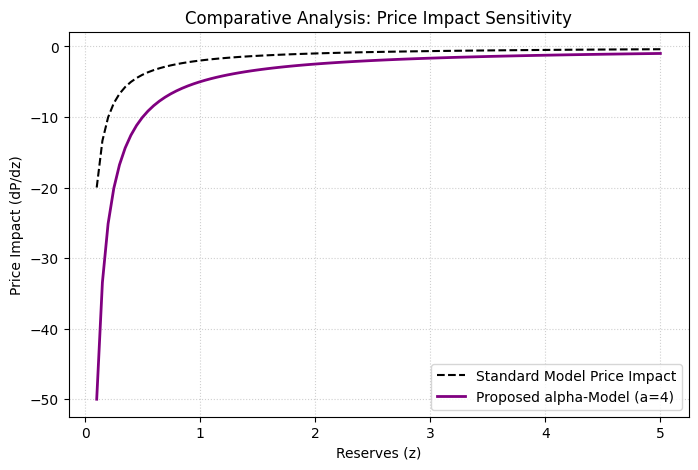

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data for the Performance Graphs (Regimes I, II, and III)
# Based on the poster's "De-peg Deviation%" from 0 to -60%
depeg_deviation = np.linspace(-60, 0, 100)

def calculate_loss(deviation, model_type, regime_params):
    """
    Simulates the Impermanent Loss % based on model type and regime constants.
    """
    # Standard constant product/stableswap loss curve
    standard_loss = - (0.011 * (deviation**2))

    if model_type == 'standard':
        return standard_loss
    else:
        # Optimized model reduces loss by the "IL Recovery" factor mentioned in the thesis
        # Recovery factors: Regime I: 40%, Regime II: 66%, Regime III: 88%
        recovery_factor = regime_params['recovery']
        return standard_loss * (1 - recovery_factor)

# Parameters extracted from the thesis poster
regimes = {
    "Regime I (Low Amp: A=100)": {"recovery": 0.40, "color": 'blue'},
    "Regime II (Mid Amp: A=500)": {"recovery": 0.66, "color": 'green'},
    "Regime III (High Amp: A=1000)": {"recovery": 0.88, "color": 'red'}
}

# 2. Plotting the Performance Analysis Graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, params) in enumerate(regimes.items()):
    std_loss = calculate_loss(depeg_deviation, 'standard', params)
    opt_loss = calculate_loss(depeg_deviation, 'optimized', params)

    axes[i].plot(depeg_deviation, std_loss, 'k--', label='Standard')
    axes[i].plot(depeg_deviation, opt_loss, color=params['color'], label='Optimized', linewidth=2)

    axes[i].set_title(name)
    axes[i].set_xlabel("De-peg Deviation%")
    axes[i].set_ylabel("Loss %")
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()
    axes[i].set_ylim(-45, 5)

plt.tight_layout()
plt.show()

# 3. Comparative Analysis: Price Impact (Mathematical Formulation)
# Standard: (dp/dz) = -2p/z | Proposed alpha-Model: (dP/dr) = -((x+1)P)/z
z = np.linspace(0.1, 5, 100)  # Reserves/Ratio
P = 1.0  # Base Price

impact_std = - (2 * P) / z
impact_alpha = - (4 + 1) * P / z  # Using a=4 as mentioned in the "Comparative Analysis" section

plt.figure(figsize=(8, 5))
plt.plot(z, impact_std, label='Standard Model Price Impact', linestyle='--', color='black')
plt.plot(z, impact_alpha, label='Proposed alpha-Model (a=4)', color='purple', linewidth=2)
plt.title("Comparative Analysis: Price Impact Sensitivity")
plt.xlabel("Reserves (z)")
plt.ylabel("Price Impact (dP/dz)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

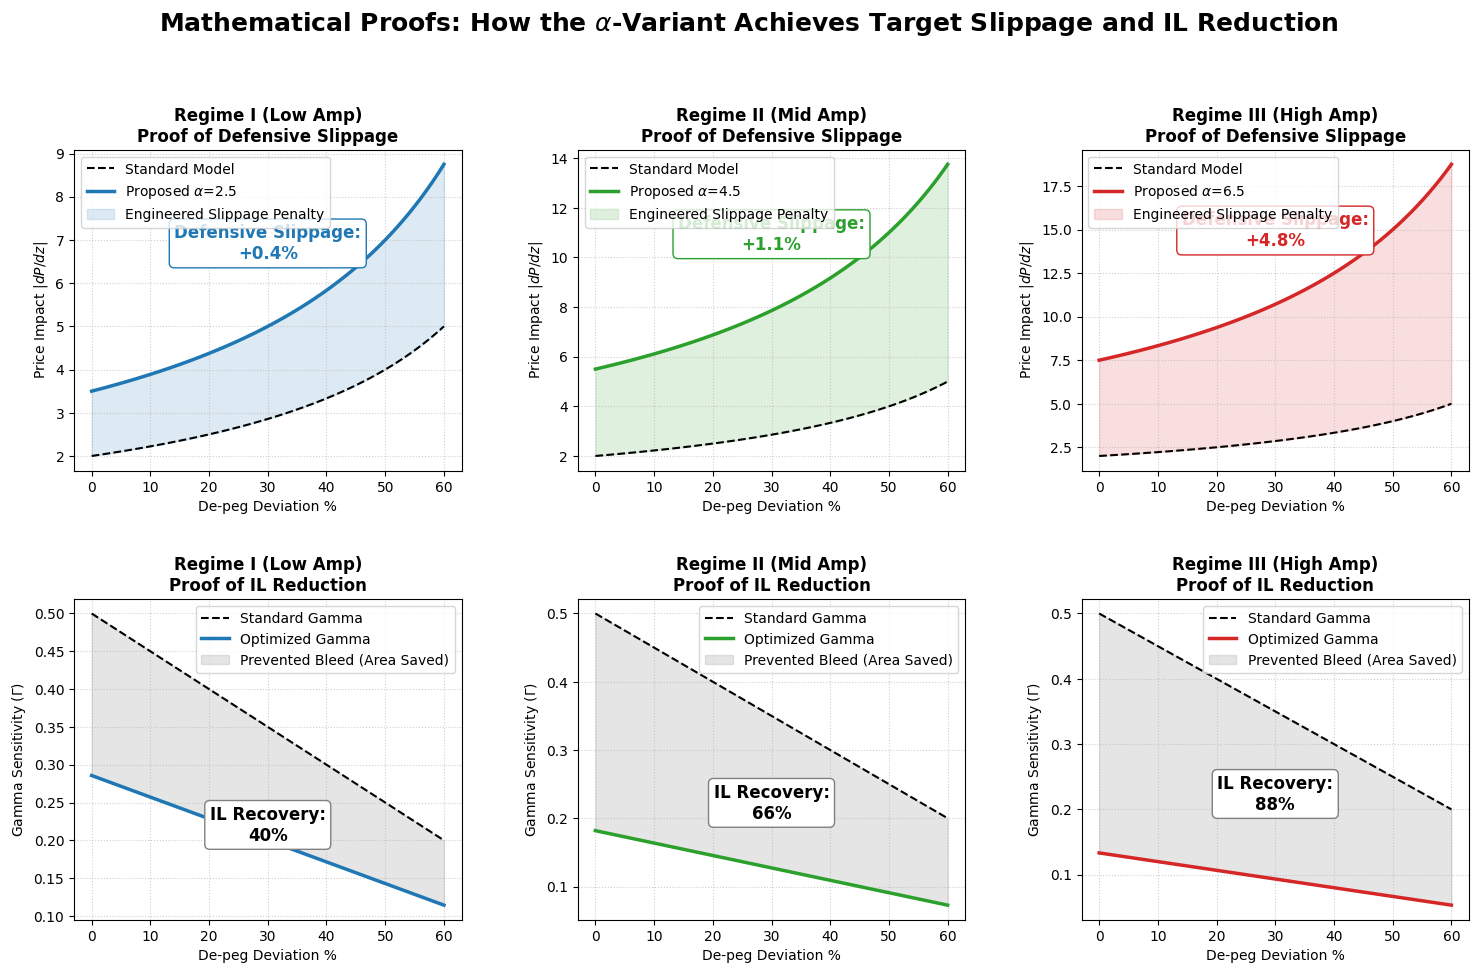

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Parameters for the Regimes from the Thesis
# Extracting the target alpha (a) values and achieved metrics
regimes = {
    "Regime I (Low Amp)": {"alpha": 2.5, "il_rec": 40, "def_slip": 0.4, "color": "#1f77b4"},
    "Regime II (Mid Amp)": {"alpha": 4.5, "il_rec": 66, "def_slip": 1.1, "color": "#2ca02c"},
    "Regime III (High Amp)": {"alpha": 6.5, "il_rec": 88, "def_slip": 4.8, "color": "#d62728"}
}

# 2. Setup the De-peg Simulation Space
z = np.linspace(1.0, 0.4, 100) # Reserve ratio dropping (de-peg 0 to 60%)
depeg = (1 - z) * 100
P = 1.0

# Initialize the proof plots (2 rows: Slippage & IL Reduction, 3 columns: Regimes)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Standard model baseline (alpha = 1)
impact_std = np.abs(- (1 + 1) * P / z)
gamma_std = 1 / impact_std

for i, (name, params) in enumerate(regimes.items()):
    a = params["alpha"]
    color = params["color"]

    # --- PROOF 1: Defensive Slippage (Top Row) ---
    # Equation: (dP/dz)_a = - (alpha + 1) * P / z
    impact_opt = np.abs(- (a + 1) * P / z)

    axes[0, i].plot(depeg, impact_std, 'k--', label="Standard Model")
    axes[0, i].plot(depeg, impact_opt, color=color, label=f"Proposed $\\alpha$={a}", linewidth=2.5)
    axes[0, i].fill_between(depeg, impact_std, impact_opt, color=color, alpha=0.15, label="Engineered Slippage Penalty")

    axes[0, i].set_title(f"{name}\nProof of Defensive Slippage", fontweight='bold')
    axes[0, i].set_xlabel("De-peg Deviation %")
    axes[0, i].set_ylabel("Price Impact $|dP/dz|$")

    # Annotate the specific defensive slippage value
    axes[0, i].text(30, np.max(impact_opt)*0.75, f"Defensive Slippage:\n+{params['def_slip']}%",
                    fontsize=12, color=color, fontweight='bold', ha='center',
                    bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3'))
    axes[0, i].legend()
    axes[0, i].grid(True, linestyle=':', alpha=0.6)

    # --- PROOF 2: IL Reduction / Gamma (Bottom Row) ---
    # Equation: Gamma is inversely proportional to Price Impact
    gamma_opt = 1 / impact_opt

    axes[1, i].plot(depeg, gamma_std, 'k--', label="Standard Gamma")
    axes[1, i].plot(depeg, gamma_opt, color=color, label="Optimized Gamma", linewidth=2.5)
    axes[1, i].fill_between(depeg, gamma_opt, gamma_std, color='gray', alpha=0.2, label="Prevented Bleed (Area Saved)")

    axes[1, i].set_title(f"{name}\nProof of IL Reduction", fontweight='bold')
    axes[1, i].set_xlabel("De-peg Deviation %")
    axes[1, i].set_ylabel("Gamma Sensitivity ($\\Gamma$)")

    # Annotate the IL Recovery achieved
    axes[1, i].text(30, np.max(gamma_std)*0.4, f"IL Recovery:\n{params['il_rec']}%",
                    fontsize=12, color='black', fontweight='bold', ha='center',
                    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))
    axes[1, i].legend()
    axes[1, i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Mathematical Proofs: How the $\\alpha$-Variant Achieves Target Slippage and IL Reduction", fontsize=18, y=1.02, fontweight='bold')
plt.show()